In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

**Loading the PreProcessed File**

In [ ]:
df = pd.read_csv("/content/insurance_final_data.csv")

In [ ]:
df.head()

,age,bmi,children,is_smoker,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3),charges
0,-1.211412,-0.407290,-0.096074,0,0,0,1,0,0,0,11915
1,1.421258,-1.676356,3.214723,0,0,1,0,0,0,0,16904
2,1.421258,-0.248656,-0.096074,0,0,0,1,0,0,0,21054
3,-1.211412,0.068610,-0.923773,0,0,0,0,1,0,0,11590
4,-0.738882,1.496310,-0.923773,1,0,0,0,0,0,1,36845


**Splitting Data into Train & Test**

- 75 to 80 percent for Training
- 25 to 20 percent for Testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns = ['charges'])
y = df['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

**Model Training**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Model Testing**

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([18242.38816397, 12765.1817022 , 19645.28847244, ...,
       35870.48474676, 17012.8704779 , 16341.13072285])

In [ ]:
y_test

,charges
856,17352
3658,11280
3344,19966
4179,5444
3869,13056
...,...
2280,9933
2924,13274
58,33325
76,15546


You might get confused by viewing the `y_test` data. bcuz it's not in proper sequence even our actual data was sorted. Reason is quiet simple we hand applied randomness using `random_state=42`.

## **Model Evaluation**

Evalutation can be done in two ways:

- r_square score
- adjusted r_square score

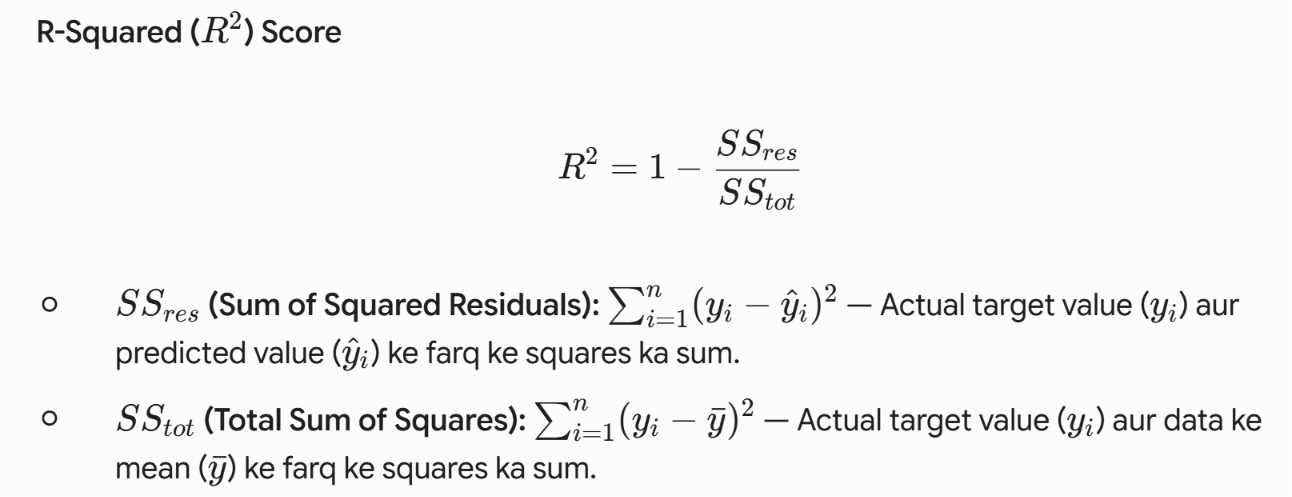

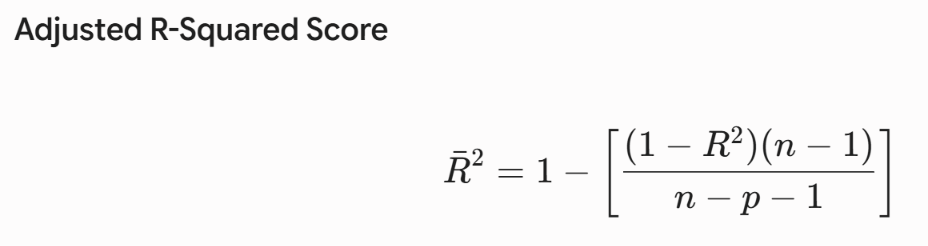

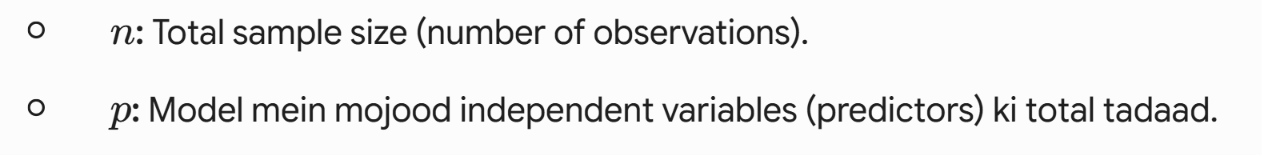

### **Key Concepts**

$R^2$ yeh batata hai ke model data ko kitna achhi tarah fit kar raha hai, jabke Adjusted $R^2$ yeh check karta hai ke kya aap ne bekar features daal kar score zabardasti toh nahi barhaya.

In dono ko aik sath dekh kar aap model ki asli performance 3 scenarios mein samajh sakte hain:

* **Well-Trained Model (Perfect Fit):**
* **$R^2$ High + Adjusted $R^2$ High (Dono kareeb hon)**
* Is ka matlab hai ke model data ko achhi tarah samajh raha hai aur jitne bhi features use hue hain woh sab meaningful hain.


* **Overfitted / Feature-Bloated Model (Fake High Score):**
* **$R^2$ High lekin Adjusted $R^2$ kafi Low (Bara gap ho)**
* Yeh warning sign hai ke aap ne extra useless features add kiye hain jo sirf $R^2$ ko artificially upar le ja rahe hain, par actual model accuracy nahi barh rahi.


* **Under-Trained Model (Underfitting):**
* **$R^2$ Low + Adjusted $R^2$ Low**
* Is ka matlab hai ke model data ke basic trends aur patterns ko hi capture nahi kar pa raha.



**Bottom Line:** Agar sirf $R^2$ dekhenge toh fazool features aap ko bewakoof bana sakte hain. Dono ka gap dekhne se pata chalta hai ke model waqai well-trained hai ya sirf noise pakad raha hai.

In [ ]:
from sklearn.metrics import r2_score, adjusted_rand_score

**Note:** Score is check on Testing Data

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.9140005783338645

In [ ]:
X_test.shape

(1641, 10)

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]


adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
adj_r2

0.9134729745199618

so our `adj_r2` is pretty close to `r2` score means the model is perfectly trained.

## **Model Performance - Hit and Trial**

Just Hit and Trial by Adding or Removing Feature to Check if we can increase the model Performance.

In [ ]:
df.head()

,age,bmi,children,is_smoker,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3),charges
0,-1.211412,-0.407290,-0.096074,0,0,0,1,0,0,0,11915
1,1.421258,-1.676356,3.214723,0,0,1,0,0,0,0,16904
2,1.421258,-0.248656,-0.096074,0,0,0,1,0,0,0,21054
3,-1.211412,0.068610,-0.923773,0,0,0,0,1,0,0,11590
4,-0.738882,1.496310,-0.923773,1,0,0,0,0,0,1,36845


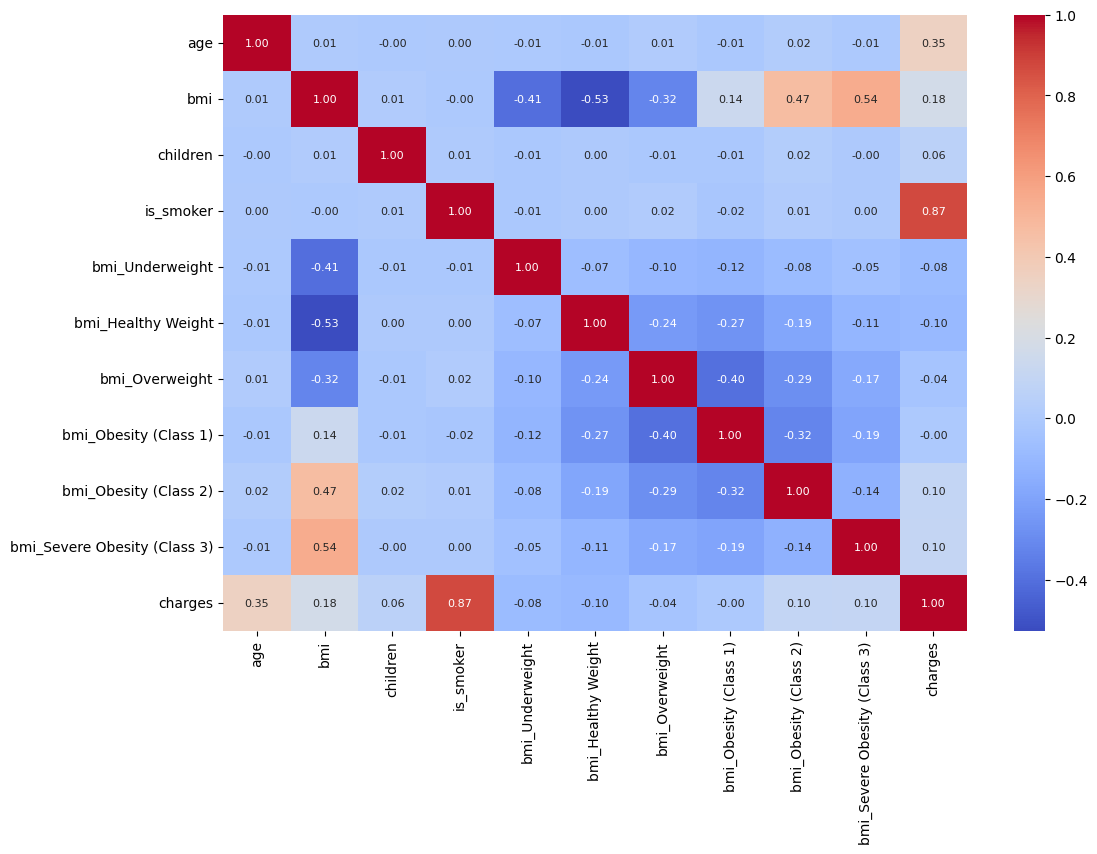

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", annot_kws={"size": 8}, cmap="coolwarm")
plt.show()

so as i have seen `children` has least correlation accross all the features so i'm dropping it.

Also intentionally i'm removing `is_smoker` as well, although it seems signifiant to me.

In [ ]:
df.drop(columns=["children", "is_smoker"])

,age,bmi,bmi_Underweight,bmi_Healthy Weight,bmi_Overweight,bmi_Obesity (Class 1),bmi_Obesity (Class 2),bmi_Severe Obesity (Class 3),charges
0,-1.211412,-0.407290,0,0,1,0,0,0,11915
1,1.421258,-1.676356,0,1,0,0,0,0,16904
2,1.421258,-0.248656,0,0,1,0,0,0,21054
3,-1.211412,0.068610,0,0,0,1,0,0,11590
4,-0.738882,1.496310,0,0,0,0,0,1,36845
...,...,...,...,...,...,...,...,...,...
4966,-0.063838,-1.359089,0,1,0,0,0,0,37611
4967,0.611206,-1.517722,0,1,0,0,0,0,15998
4968,0.543702,-1.041823,0,1,0,0,0,0,16229
4969,-0.266351,-0.090023,0,0,0,1,0,0,13709


In [ ]:
X_new = df.drop(columns=["charges"])
y_new = df["charges"]

In [ ]:
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [ ]:
model_new = LinearRegression()
model_new.fit(X_new_train, y_new_train)

LinearRegression()

In [ ]:
y_new_pred = model_new.predict(X_new_test)

In [ ]:
r2_new = r2_score(y_new_test, y_new_pred)
r2_new

0.916494079987366

In [ ]:
n = X_new_test.shape[0]
p = X_new_test.shape[1]


adj_r2_new = 1 - (1 - r2_new) * ((n - 1) / (n - p - 1))
adj_r2_new

0.9156454425888636

**Results:** I first removed children only and it reduces my model performance but when i removed smoker along with children **surprisingly it increased model performance.**